# EPInformer reproduction — visualize prediction results

Loads the out-of-fold predictions written by `train_EPInformer.py` (gene expression)
and `train_seqEncoder.py` (enhancer-activity encoder) and visualizes them:

1. Gene expression: predicted vs observed scatter (pooled 12-fold) + per-fold Pearson R
2. Enhancer-activity encoder: predicted vs observed log2 activity
3. Compare cell lines (headline **f3**) + feature ablation (f1/f2/f3)

**Headline (pooled 12-fold out-of-fold Pearson R):**
- **Encoder** (log2 activity): H1 0.820 · HepG2 0.743 · K562 0.740 · HUVEC 0.742 · NHEK 0.677 · GM12878 0.617
- **Expression**, shipped **f3** = frozen encoder + 3 enhancer features + promoter signal:
  - RNA: K562 0.856 · GM12878 0.860 · HepG2 0.845 · HUVEC 0.839 · NHEK 0.828 · H1 0.781
  - CAGE: K562 0.867 · GM12878 0.890  (CAGE labels exist only for K562/GM12878)

## Configuration
Edit the paths to point at your training / seqEncoder output directories.

In [1]:
%matplotlib inline
import os, glob
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
try:
    import seaborn as sns; sns.set_style('whitegrid')
    HAS_SNS = True
except Exception:
    HAS_SNS = False

# --- EDIT THIS ---
CELL = 'K562'
# ------------------
# Headline (shipped f3) output dirs, resolved per cell:
#   expression: K562/GM12878 = {cell}_repro_RNA_prm ; H1/HepG2/HUVEC/NHEK = {cell}_repro_RNA
#               (CAGE for K562/GM12878: {cell}_repro_CAGE[_consistentBAM]_prm ; ablation: {cell}_repro_RNA_f{1,2,3})
#   encoder:    K562 = K562_repro (5-bin headline, R~0.74; NOT results/seqencoder/K562 = 3-bin baseline 0.66)
#               GM12878 = GM12878 ; other cells = {cell}
_EXPR_DIR = {'K562': 'K562_repro_RNA_prm', 'GM12878': 'GM12878_repro_RNA_consistentBAM_prm'}
_ENC_DIR  = {'K562': 'K562_repro'}
EXPR_PRED_DIR    = f"./EPInformer_models/{_EXPR_DIR.get(CELL, CELL + '_repro_RNA')}"
ENCODER_PRED_DIR = f"./results/seqencoder/{_ENC_DIR.get(CELL, CELL)}"
print('expression preds:', EXPR_PRED_DIR)
print('encoder preds   :', ENCODER_PRED_DIR)

expression preds: ./EPInformer_models/K562_repro_RNA_prm
encoder preds   : ./results/seqencoder/K562_repro


In [2]:
def metrics(pred, actual):
    pred, actual = np.asarray(pred, float), np.asarray(actual, float)
    ok = np.isfinite(pred) & np.isfinite(actual); pred, actual = pred[ok], actual[ok]
    r = stats.pearsonr(pred, actual)[0]; rho = stats.spearmanr(pred, actual)[0]
    return dict(pearsonr=r, spearmanr=rho, r2=r**2, mse=float(np.mean((pred-actual)**2)), n=len(pred))

def load_expression(pred_dir):
    # prefer the per-fold files (one per array task) -> reliable pooled OOF
    files = sorted(glob.glob(os.path.join(pred_dir, 'fold_*_predictions.csv')))
    if files:
        frames = []
        for f in files:
            d = pd.read_csv(f); pc = 'Pred' if 'Pred' in d.columns else 'pred'
            frames.append(pd.DataFrame({'pred': d[pc], 'actual': d['actual'],
                                        'fold': d['fold_idx'].iloc[0] if 'fold_idx' in d.columns else -1}))
        return pd.concat(frames, ignore_index=True)
    res = sorted(glob.glob(os.path.join(pred_dir, '*_results.csv')))   # single-process fallback
    if res:
        df = pd.read_csv(res[0]); pc = 'Pred' if 'Pred' in df.columns else 'pred'
        fc = 'fold_idx' if 'fold_idx' in df.columns else 'fold'
        return pd.DataFrame({'pred': df[pc], 'actual': df['actual'], 'fold': df.get(fc, -1)})
    raise FileNotFoundError(f'no predictions in {pred_dir}')

def load_encoder(pred_dir):
    files = sorted(glob.glob(os.path.join(pred_dir, 'predictions', 'fold_*_predictions.csv'))) or \
            sorted(glob.glob(os.path.join(pred_dir, 'fold_*_predictions.csv')))
    files = [f for f in files if 'summit_only' not in os.path.basename(f)]
    frames = []
    for f in files:
        d = pd.read_csv(f); pc = 'preds' if 'preds' in d.columns else ('Pred' if 'Pred' in d.columns else 'pred')
        fold = os.path.basename(f).split('_')[1]
        frames.append(pd.DataFrame({'pred': d[pc], 'actual': d['actual'], 'fold': fold}))
    if not frames: raise FileNotFoundError(f'no predictions in {pred_dir}')
    return pd.concat(frames, ignore_index=True)

## 1. Gene expression — pooled out-of-fold predictions

In [3]:
expr = load_expression(EXPR_PRED_DIR)
m = metrics(expr['pred'], expr['actual'])
print(f"{CELL}: n={m['n']}  Pearson R={m['pearsonr']:.4f}  R^2={m['r2']:.4f}  "
      f"Spearman={m['spearmanr']:.4f}  MSE={m['mse']:.4f}")

K562: n=18377  Pearson R=0.8564  R^2=0.7334  Spearman=0.8326  MSE=0.2679


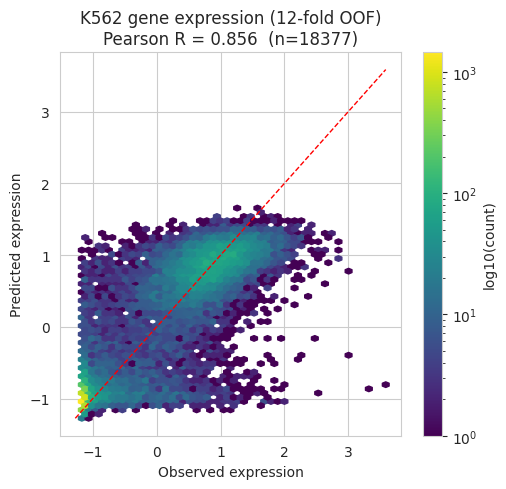

In [4]:
# predicted vs observed scatter (density) for the pooled 12-fold predictions
fig, ax = plt.subplots(figsize=(5.2, 5))
hb = ax.hexbin(expr['actual'], expr['pred'], gridsize=45, cmap='viridis', mincnt=1, bins='log')
lo = float(min(expr['actual'].min(), expr['pred'].min())); hi = float(max(expr['actual'].max(), expr['pred'].max()))
ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
ax.set_xlabel('Observed expression'); ax.set_ylabel('Predicted expression')
ax.set_title(f'{CELL} gene expression (12-fold OOF)\nPearson R = {m["pearsonr"]:.3f}  (n={m["n"]})')
fig.colorbar(hb, ax=ax, label='log10(count)'); fig.tight_layout(); plt.show()

/home/user/tmp/ipykernel_217366/136289907.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pf = expr.groupby('fold').apply(lambda g: metrics(g['pred'], g['actual'])['pearsonr']).sort_index()


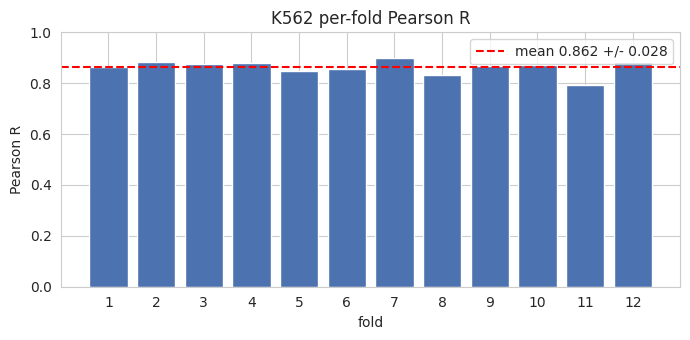

In [5]:
# per-fold Pearson R
pf = expr.groupby('fold').apply(lambda g: metrics(g['pred'], g['actual'])['pearsonr']).sort_index()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(pf.index.astype(str), pf.values, color='#4C72B0')
ax.axhline(pf.mean(), color='r', ls='--', label=f'mean {pf.mean():.3f} +/- {pf.std():.3f}')
ax.set_xlabel('fold'); ax.set_ylabel('Pearson R'); ax.set_ylim(0, 1); ax.legend()
ax.set_title(f'{CELL} per-fold Pearson R'); fig.tight_layout(); plt.show()

## 2. Enhancer activity encoder — predicted vs observed log2 activity

K562 encoder: n=273125  Pearson R=0.7382  R^2=0.5450


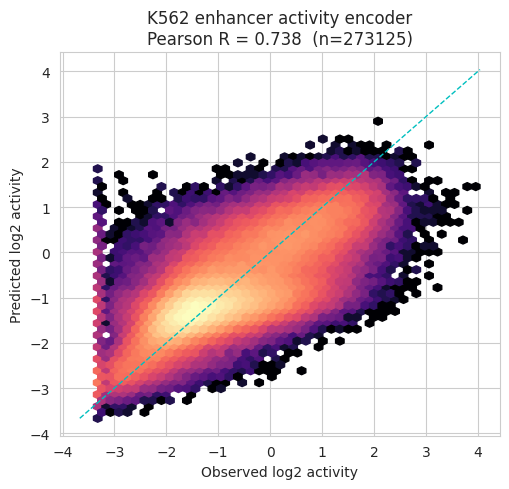

In [6]:
try:
    enc = load_encoder(ENCODER_PRED_DIR)
    me = metrics(enc['pred'], enc['actual'])
    print(f"{CELL} encoder: n={me['n']}  Pearson R={me['pearsonr']:.4f}  R^2={me['r2']:.4f}")
    fig, ax = plt.subplots(figsize=(5.2, 5))
    ax.hexbin(enc['actual'], enc['pred'], gridsize=45, cmap='magma', mincnt=1, bins='log')
    lo = float(min(enc['actual'].min(), enc['pred'].min())); hi = float(max(enc['actual'].max(), enc['pred'].max()))
    ax.plot([lo, hi], [lo, hi], 'c--', lw=1)
    ax.set_xlabel('Observed log2 activity'); ax.set_ylabel('Predicted log2 activity')
    ax.set_title(f'{CELL} enhancer activity encoder\nPearson R = {me["pearsonr"]:.3f}  (n={me["n"]})')
    fig.tight_layout(); plt.show()
except FileNotFoundError as e:
    print('encoder predictions not found yet — run train_seqEncoder.py first:', e)

## 3. Compare cell lines / feature variants (optional)
Point at multiple training output dirs to tabulate Pearson R side by side.

In [7]:
# Headline f3 (RNA) = frozen encoder + 3 enh feats + promoter signal, per cell
COMPARE = {
    'K562':    './EPInformer_models/K562_repro_RNA_prm',
    'GM12878': './EPInformer_models/GM12878_repro_RNA_consistentBAM_prm',
    'HepG2':   './EPInformer_models/HepG2_repro_RNA',
    'HUVEC':   './EPInformer_models/HUVEC_repro_RNA',
    'NHEK':    './EPInformer_models/NHEK_repro_RNA',
    'H1':      './EPInformer_models/H1_repro_RNA',
}
rows = []
for name, d in COMPARE.items():
    try:
        mm = metrics(*[load_expression(d)[c] for c in ('pred', 'actual')])
        rows.append(dict(cell=name, **{k: round(mm[k], 4) for k in ('pearsonr', 'r2', 'spearmanr', 'n')}))
    except Exception as e:
        print(f'skip {name}: {e}')
pd.DataFrame(rows)

,cell,pearsonr,r2,spearmanr,n
0,K562,0.8564,0.7334,0.8326,18377
1,GM12878,0.8602,0.7399,0.8320,18377
2,HepG2,0.8447,0.7135,0.8153,18377
3,HUVEC,0.8390,0.7039,0.8176,18377
4,NHEK,0.8281,0.6857,0.7948,18377
5,H1,0.7811,0.6101,0.7510,18377


## 4. Feature ablation (RNA, no prm)
f1 = distance · f2 = +activity · f3 = +Hi-C. Activity dominates; Hi-C is ~inert; the promoter signal (shipped f3) adds ~+0.01 on top of f3.

In [8]:
ABLATION = ['HepG2', 'HUVEC', 'NHEK', 'H1']
rows = []
for cell in ABLATION:
    row = {'cell': cell}
    for k in (1, 2, 3):
        d = f'./EPInformer_models/{cell}_repro_RNA_f{k}'
        try:
            row[f'f{k}'] = round(metrics(*[load_expression(d)[c] for c in ('pred','actual')])['pearsonr'], 4)
        except Exception:
            row[f'f{k}'] = None
    d = f'./EPInformer_models/{cell}_repro_RNA'  # f3 + prm (shipped)
    try:
        row['f3+prm'] = round(metrics(*[load_expression(d)[c] for c in ('pred','actual')])['pearsonr'], 4)
    except Exception:
        row['f3+prm'] = None
    rows.append(row)
pd.DataFrame(rows)

,cell,f1,f2,f3,f3+prm
0,HepG2,0.6340,0.8382,0.8354,0.8447
1,HUVEC,0.6304,0.8269,0.8292,0.8390
2,NHEK,0.6053,0.8177,0.8171,0.8281
3,H1,0.6608,0.7800,0.7721,0.7811
